In [10]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf 
import matplotlib.pyplot as plt

In [3]:
def test_lc(path):

    LC_COLUMN = "lc"

    catalog = read_hats(
        path,    
    ).map_partitions(
        lambda df: df.assign(
            **{LC_COLUMN: df[LC_COLUMN].astype(NestedDtype.from_pandas_arrow_dtype(df.dtypes[LC_COLUMN]))},
        )
    )

    with Client() as client:
        # display(client)
        df = catalog.compute()
    
    return df
path='/media3/majumder/dataset/cepheids/hats/zubercal_vcep'
df = test_lc(path)

In [ ]:

id_=1085440417799958669
data = pd.DataFrame(df[df.index==id_]["lc"].values[0])
data["band"].replace({"i": "#e8ce3c", "r": "#297560", "g": "#221442"}, inplace=True)

In [108]:
hid = [2214796789392420138,
        2215747173394139728,
        509779825764154648,
        595072387673099010,
        2214357841673687294,
        2213985306096277960,
        591476440637045108,
        422648561147798206,
        2211209620212458611,
        2210913752747011045]

In [11]:
from astra.utils.helper import deserialize_for_inference
OFFSET = 58000.0
count=0
counter = 600
band_map = {
    'green': np.float64(3.676371655248864),
    'red': np.float64(3.803892557467166),
    'black': np.float64(3.8937079572375954)
}

# --- The Solution ---
mapped_labels = []
filenames = list()
path = f"/home/nvidia/workplace/dataset/training_data/train/partition_0/AGN/"
#
#
#
glob_pattern = os.path.join(path, '*.record')
filenames = tf.data.Dataset.list_files(glob_pattern, shuffle=False)
num_files_found = tf.data.experimental.cardinality(filenames)
print(f"Number of files found: {num_files_found.numpy()}")
#
#
#
dataset = tf.data.TFRecordDataset(filenames)
#
#
#
for rec in dataset.take(1):
    #
    example = tf.train.SequenceExample()
    example.ParseFromString(rec.numpy())
    #
    last_index = example.context.feature['last_index'].int64_list.value
    label_cls = example.context.feature['label'].bytes_list.value
    label_cls = label_cls[0].decode('utf-8')
    bands = example.context.feature['bands'].bytes_list.value
    # bands = bands.decode('utf-8')
    time = tf.convert_to_tensor(example.feature_lists.feature_list['dim_0'].feature[0].float_list.value , dtype=tf.float64) + OFFSET
    # time = example.feature_lists.feature_list['dim_0'].feature[0].float_list.value
    mag = example.feature_lists.feature_list['dim_1'].feature[0].float_list.value
    mag_err = example.feature_lists.feature_list['dim_2'].feature[0].float_list.value
    band_sorted = example.feature_lists.feature_list['dim_3'].feature[0].float_list.value
    last_index = example.context.feature['last_index'].int64_list.value
    id_ = example.context.feature['id'].int64_list.value[0]
    
    print("ID: ", id_)
    print("Label: ", label_cls)
    print("Last Index: ", last_index)
    print("bands: ", bands)
       
for rec in dataset.take(1):
    input_dict = deserialize_for_inference(rec)

print("Input keys: ", input_dict.keys())
print(min(time), max(time), len(time))

Number of files found: 46
ID:  21471581925667603
Label:  AGN
Last Index:  [452, 1319, 1328]
bands:  [b'g', b'r', b'i']
Input keys:  dict_keys(['id', 'last_index', 'label', 'bands', 'input_id'])


2026-02-02 09:05:43.187671: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


tf.Tensor(58316.466552734375, shape=(), dtype=float64) tf.Tensor(59940.26184082031, shape=(), dtype=float64) 1329


In [30]:
# Your input data and mapping dictionary
# band_sorted = np.array([3.67637157, 3.80389261, 3.89370799])
band_map = {
    'green': np.float64(3.676371655248864),
    'red': np.float64(3.803892557467166),
    'black': np.float64(3.8937079572375954)
}

# --- The Solution ---
mapped_labels = []
for value_to_map in band_sorted:
    found_match = False
    for label, target_value in band_map.items():
        # np.isclose() checks if the two numbers are close within a small tolerance
        if np.isclose(value_to_map, target_value):
            mapped_labels.append(label)
            found_match = True
            break # Move to the next value in band_sorted
    
    if not found_match:
        mapped_labels.append('Unknown') # Handle cases where no close match is found

result_array = np.array(mapped_labels)

# print("--- Readable Loop-based Solution ---")
# print(f"Original array: {band_sorted}")
# print(f"Mapped array:   {result_array}")

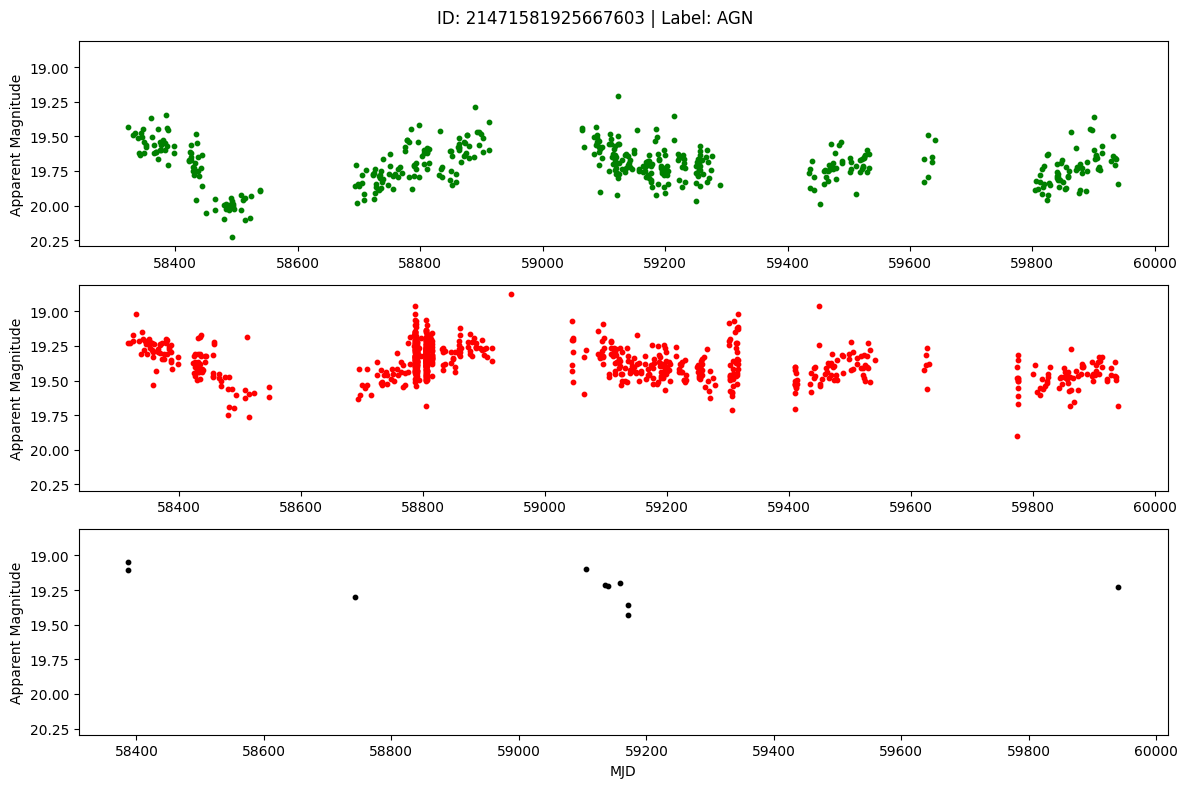

In [12]:
# plt.figure(figsize=(12, 8))
# plt.suptitle(f"ID: {id_} | Label: {label_cls}")
# plt.subplot(3, 1, 1)
# plt.scatter(time[:208], mag[:208], s=10, c="green")
# plt.gca().invert_yaxis()  # <--- Invert immediately
# plt.ylabel("Apparent Magnitude")
# plt.subplot(3, 1, 2)
# plt.scatter(time[208:957], mag[208:957], s=10, c="red")
# plt.gca().invert_yaxis()  # <--- Invert immediately
# plt.ylabel("Apparent Magnitude")
# plt.subplot(3, 1, 3)
# plt.scatter(time[957:], mag[957:], s=10, c="black")
# plt.gca().invert_yaxis()  # <--- Invert immediately
# plt.ylabel("Apparent Magnitude")
# plt.xlabel("MJD")
# plt.show()
# Create 3 rows, sharing the Y-axis range
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharey=True)

fig.suptitle(f"ID: {id_} | Label: {label_cls}")

# Plot 1
axes[0].scatter(time[:452], mag[:452], s=10, c="green")
axes[0].invert_yaxis() # You only need to call this once if sharey=True!

# Plot 2
axes[1].scatter(time[452:1319], mag[452:1319], s=10, c="red")
# axes[1].invert_yaxis() # Not needed if sharey=True

# Plot 3
axes[2].scatter(time[1319:], mag[1319:], s=10, c="black")
# axes[2].invert_yaxis() # Not needed if sharey=True

# Set labels
for ax in axes:
    ax.set_ylabel("Apparent Magnitude")

axes[2].set_xlabel("MJD")

plt.tight_layout()
plt.show()

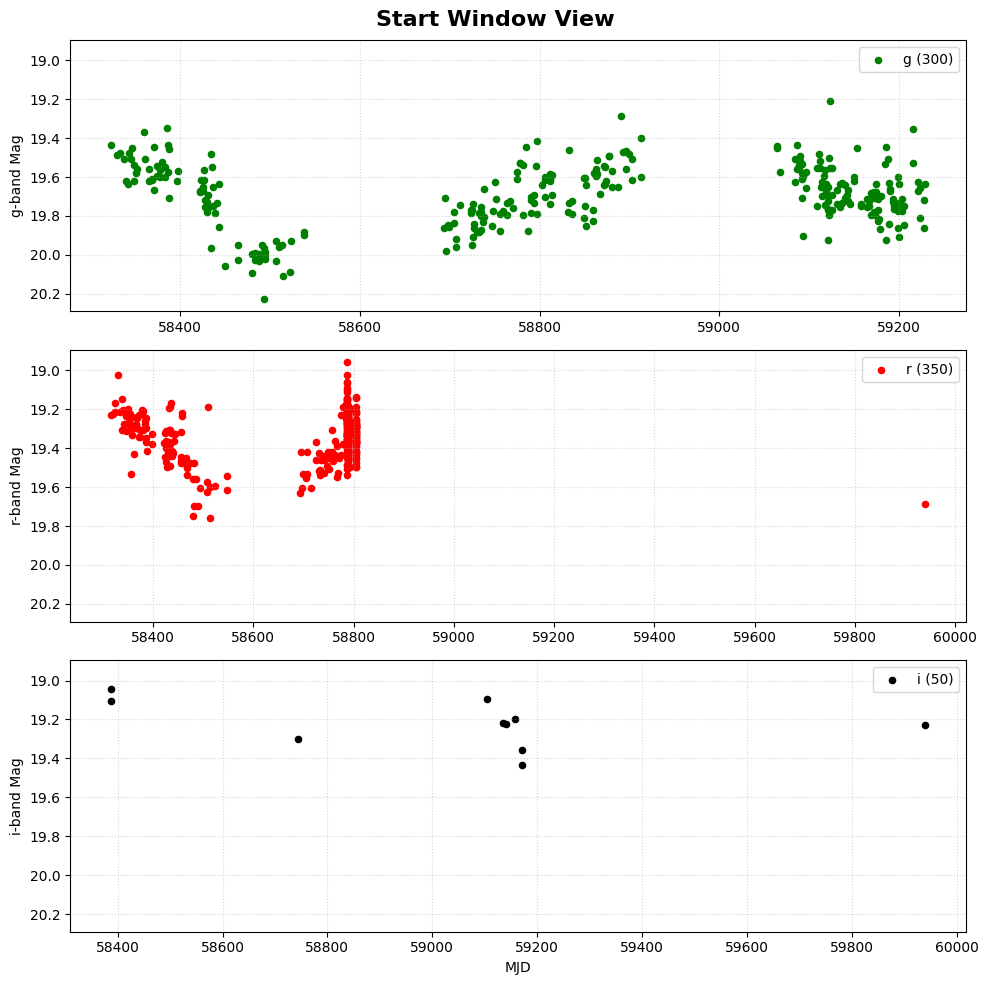

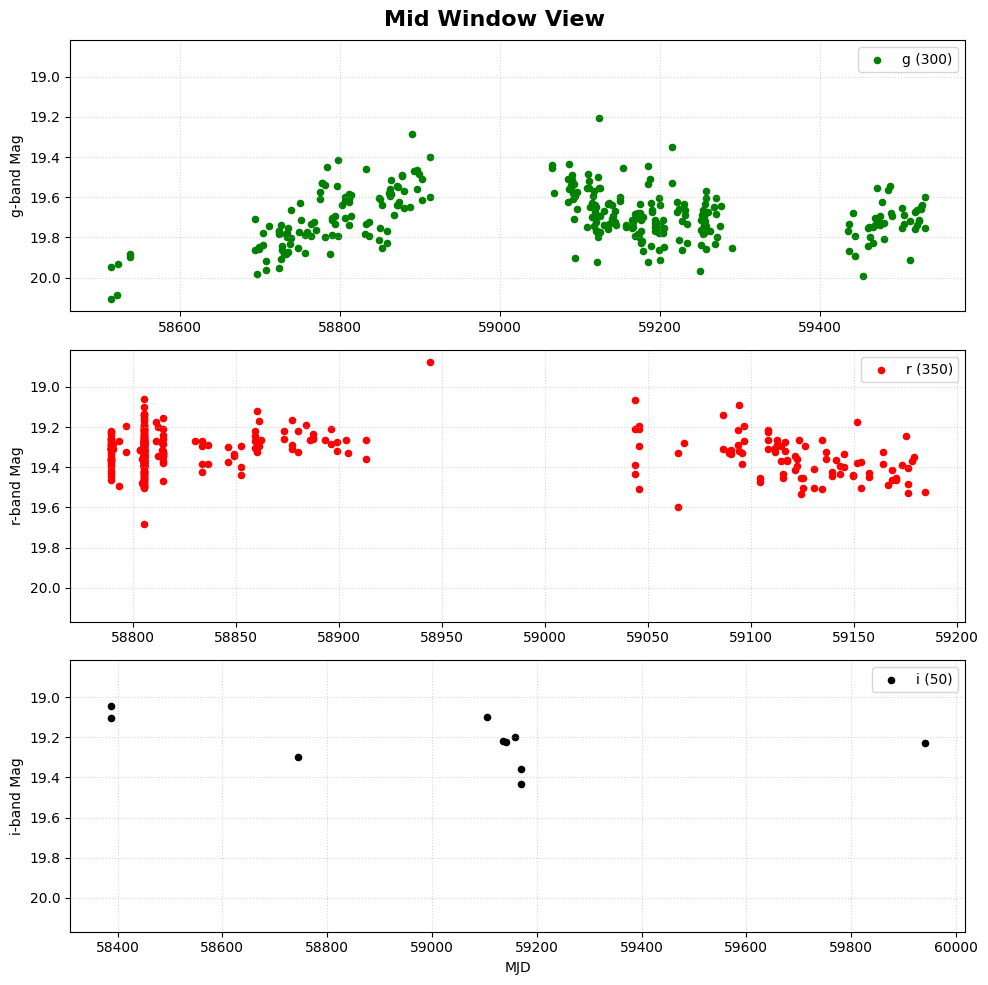

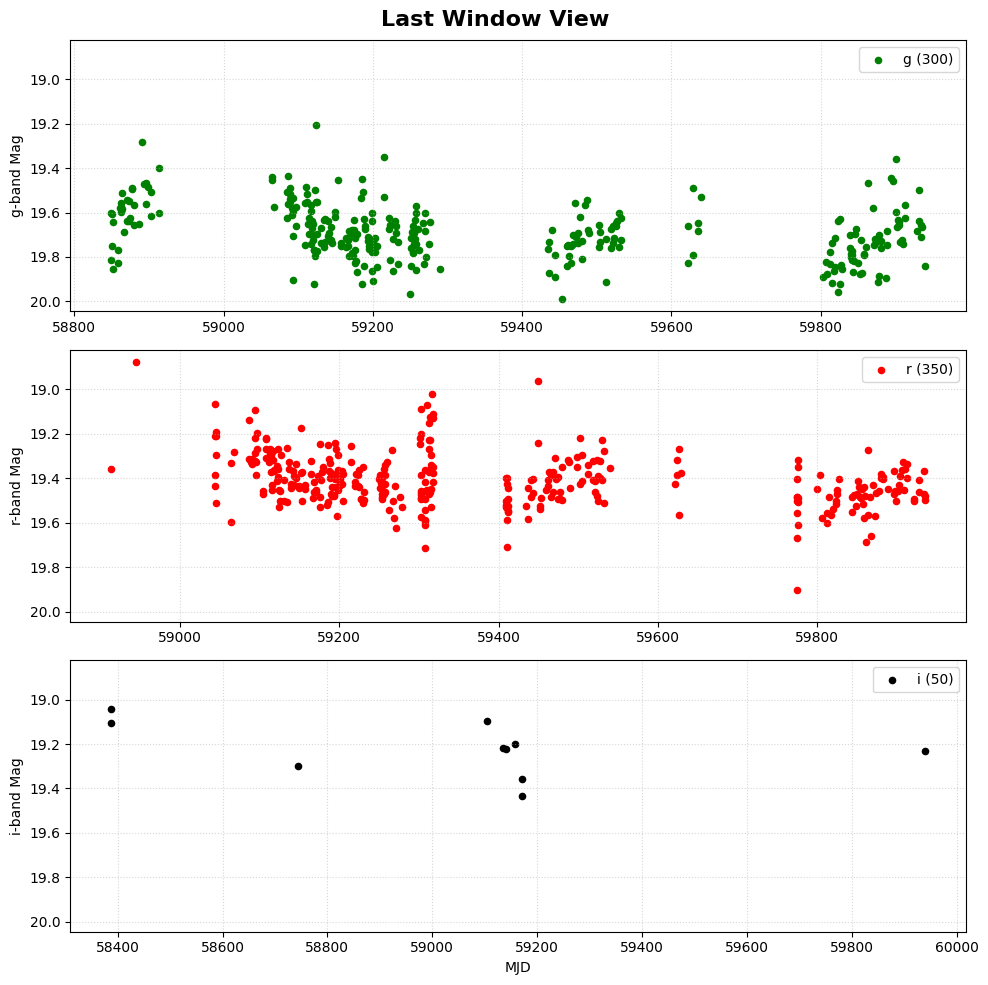

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def to_numpy(data):
    """Helper to convert Tensor to Numpy if needed."""
    if hasattr(data, 'numpy'):
        return data.numpy()
    return np.array(data)

def get_band_window(time, mag, required_count, window_type='start'):
    """
    Extracts a specific window from a single band and pads with zeros if needed.
    Returns NumPy arrays.
    """
    # Convert input to numpy to avoid TensorFlow errors in Matplotlib
    time = to_numpy(time)
    mag = to_numpy(mag)
    
    n_points = len(mag)
    
    # --- Logic 1: Handle Padding if data is too short ---
    if n_points < required_count:
        # Create zero arrays of the required length
        padded_time = np.zeros(required_count)
        padded_mag = np.zeros(required_count)
        
        # Fill the beginning with available data
        # (For plotting purposes, we usually anchor to the left, 
        # but masking makes the visual identical)
        padded_time[:n_points] = time
        padded_mag[:n_points] = mag
        return padded_time, padded_mag

    # --- Logic 2: Extract Slice based on Window Type ---
    if window_type == 'start':
        t_slice = time[:required_count]
        m_slice = mag[:required_count]
        
    elif window_type == 'last':
        t_slice = time[-required_count:]
        m_slice = mag[-required_count:]
        
    elif window_type == 'mid':
        mid_idx = n_points // 2
        half_window = required_count // 2
        
        start_idx = max(0, mid_idx - half_window)
        end_idx = start_idx + required_count
        
        # Adjust if we hit the boundary
        if end_idx > n_points:
            end_idx = n_points
            start_idx = max(0, end_idx - required_count)
            
        t_slice = time[start_idx:end_idx]
        m_slice = mag[start_idx:end_idx]

    return t_slice, m_slice

def plot_separate_windows(lc_data):
    """
    Generates 3 separate images (Start, Mid, Last).
    Each image has 3 subplots for g, r, i bands.
    """
    
    # Settings
    bands = ['g', 'r', 'i']
    colors = {'g': 'green', 'r': 'red', 'i': 'black'}
    # The counts you requested
    counts = {'g': 300, 'r': 350, 'i': 50} 
    window_types = ['start', 'mid', 'last']
    
    # --- Main Loop: Create 1 Figure per Window Type ---
    for w_type in window_types:
        
        # Create a new Figure for this window type
        fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharey=True)
        fig.suptitle(f"{w_type.capitalize()} Window View", fontsize=16, fontweight='bold')
        
        # Loop through bands for the rows
        for i, band in enumerate(bands):
            ax = axes[i]
            
            # Safe extraction in case a band is missing from input
            if band in lc_data:
                t_raw, m_raw = lc_data[band]
                req_n = counts[band]
                
                # Get the slice (Numpy arrays)
                t_win, m_win = get_band_window(t_raw, m_raw, req_n, window_type=w_type)
                
                # --- The Fix for "Mask cannot be scalar" ---
                # Since t_win/m_win are now definitely numpy arrays, this works:
                mask = m_win != 0 
                
                if np.sum(mask) > 0:
                    ax.scatter(t_win[mask], m_win[mask], 
                               s=20, c=colors[band], label=f'{band} ({req_n})')
                else:
                    ax.text(0.5, 0.5, "Insufficient Data / Padding Only", 
                            transform=ax.transAxes, ha='center')
            
            # Formatting
            ax.set_ylabel(f"{band}-band Mag")
            ax.invert_yaxis() # Invert Y for every subplot
            ax.legend(loc='upper right')
            ax.grid(True, linestyle=':', alpha=0.5)
            
            # Only put X-label on the bottom plot
            if i == 2:
                ax.set_xlabel("MJD")

        plt.tight_layout()
        plt.show() # Displays the figure for this window type

# data = {
#     'g': generate_mock_lc(800),  # Enough for all windows
#     'r': generate_mock_lc(1000), # Plenty of data
#     'i': generate_mock_lc(100)   # Short! (Will trigger zero-padding logic)
# }
data = {
    'g': (time[:452], mag[:452]),  
    'r': (time[452:1319], mag[452:1319]), 
    'i': (time[1319:], mag[1319:])   # Uncomment if you want to include 'i' band
}

# 2. Run the Plotter
plot_separate_windows(data)

In [ ]:
from astra.src.preprocessing import multiview_window_generator, sliding_window
ztf_band = {'g': np.log10(4746.48), 'r': np.log10(6366.38), 'i': np.log10(7829.03)}

max_len_dict = {'g': 300, 'r': 350, 'i': 50}

def visualize_generated_views(input_dict):
    """
    Takes raw input dictionary, runs the generator, and plots the result.
    """
    # 1. Prepare raw input tensors
    # Concatenate features as expected by the generator (MJD, Mag, Err, Band)
    # features = input_dict['input_id']
    features = input_dict['input_id']
    mags, magerrs = features[:, 1], features[:, 2]
    # (Skipping standardization for visual clarity, using raw Mags)
    
    processed_features = tf.concat([
                                    features[:, 0:1], # MJD (Col 0)
                                    tf.reshape(mags, (-1,1)), # Mag (Col 1)
                                    features[:, 2:] # Err, Band (Col 2, 3)
                                ], axis=1)
    
    initial_mask = tf.zeros(tf.shape(mags)[0], dtype=tf.float32)
    # (Skipping standardization for visual clarity, using raw Mags)
    
    

    # 2. RUN THE GENERATOR
    # Output Shape: (3, Total_Len, 4) -> [Start, Mid, End]
    views_feat, views_mask = multiview_window_generator(
        processed_features, 
        initial_mask, 
        input_dict['last_index'], 
        input_dict['bands'], 
        max_len_dict
    )
    # views_feat, views_mask = sliding_window(
    #     processed_features, 
    #     initial_mask, 
    #     input_dict['last_index'], 
    #     input_dict['bands'], 
    #     max_len_dict
    # )
    x = tf.expand_dims(views_feat[:,:, 1], axis=-1) 
    # 3. Convert to Numpy for Plotting
    views_np = views_feat.numpy()
    mask_np = views_mask.numpy()
    x = x.numpy()
    print(views_np.shape, mask_np.shape, x.shape)
    
    # 4. Plotting
    fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharey=True)
    
    view_names = ["Start View", "Mid View", "End View"]
    colors = {'g': 'green', 'r': 'red', 'i': 'black'} # Band IDs: g=0, r=1, i=2
    
    
    for i in range(3): # Loop over views
        ax = axes[i]
        data = views_np[i] # (Total_Len, 4)
        mask = mask_np[i]  # (Total_Len,)
        times = data[:, 0] 
        mags = data[:, 1]
        # print(mags)
        # Scatter plot different bands with different colors
        start_idx = 0
        for fil, size_ in max_len_dict.items():
        
            end_idx = start_idx + size_
            at = times[start_idx:end_idx]
            at = at[mask[start_idx:end_idx]==0]+OFFSET
            am = mags[start_idx:end_idx]
            am = am[mask[start_idx:end_idx]==0]
            ax.scatter(at, am, 
                        s=20, c=colors[fil],label=f"{fil}-band", alpha=0.7)
            
            start_idx = end_idx
            
            ax.set_title(f"{view_names[i]}", fontsize=12, fontweight='bold')
            ax.invert_yaxis()
            ax.set_ylabel("App. Magnitude")
            ax.legend(loc='lower right')
            ax.grid(True, linestyle=':', alpha=0.5)

    axes[2].set_xlabel("MJD")
    plt.tight_layout()
    plt.show()

    

visualize_generated_views(input_dict)
# (3, 700, 4) (3, 700)
# (700, 4) (700,)


(3, 700, 4) (3, 700) (3, 700, 1)
